1. Data Understanding

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('IMDB Dataset.csv')

# Check the dimensions to ensure you got all 50k rows
print(f"Dataset Shape: {df.shape}")

# Check for class imbalance
print("\nClass Distribution:")
print(df['sentiment'].value_counts())

# Look at the first row of raw text to see what needs cleaning
print("\nRaw Text Example:")
print(df.head)

: 

NLP preprocessing

In [4]:
#Install & Download NLTK
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [5]:
#Import Required Libraries
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [6]:
#Initialize Tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [8]:
import re

def preprocess_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+", "", text)     # remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text) # remove special chars

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [9]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [21]:
#Apply Preprocessing
df['clean_text'] = df['review'].apply(preprocess_text)


In [25]:
df.columns

Index(['review', 'sentiment', 'clean_text'], dtype='object')

4. FEATURE ENGINEERING


In [15]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

In [26]:
# Bag of Words
bow = CountVectorizer()
X_bow = bow.fit_transform(df['clean_text'])

In [29]:
# TF-IDF
tfidf = TfidfVectorizer()
x_tfidf = tfidf.fit_transform(df['clean_text'])
y_tfidf = df['sentiment']

TRAIN TEST SPLIT

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    x_tfidf, y_tfidf,test_size=0.2, random_state=42
)

Model Training

In [32]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [33]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [34]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

EVALUATION FUNCTION

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_test, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_nb, "Naive Bayes")
evaluate(y_test, y_pred_dt, "Decision Tree")


Logistic Regression
Accuracy: 0.8945
Precision: 0.8947575480520629
Recall: 0.8945
F1 Score: 0.8944703803480348

Naive Bayes
Accuracy: 0.8665
Precision: 0.86704072764602
Recall: 0.8665
F1 Score: 0.8664735706491036

Decision Tree
Accuracy: 0.7178
Precision: 0.7177964685408387
Recall: 0.7178
F1 Score: 0.7177975164476736


Comparison Table

In [39]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_nb, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted')
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.8945,0.894470
1,Naive Bayes,0.8665,0.866474
2,Decision Tree,0.7178,0.717798


BONUS :Confusion Matrix

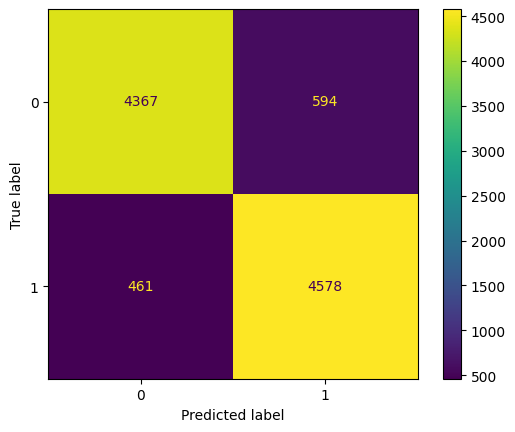

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

**Insights**


- TF-IDF provided better results compared to simple methods due to word importance weighting.
- Logistic Regression achieved the highest accuracy among all models.
- Naive Bayes performed well due to its probabilistic nature.
- Decision Tree showed lower performance and possible overfitting.
- Preprocessing significantly improved model performance